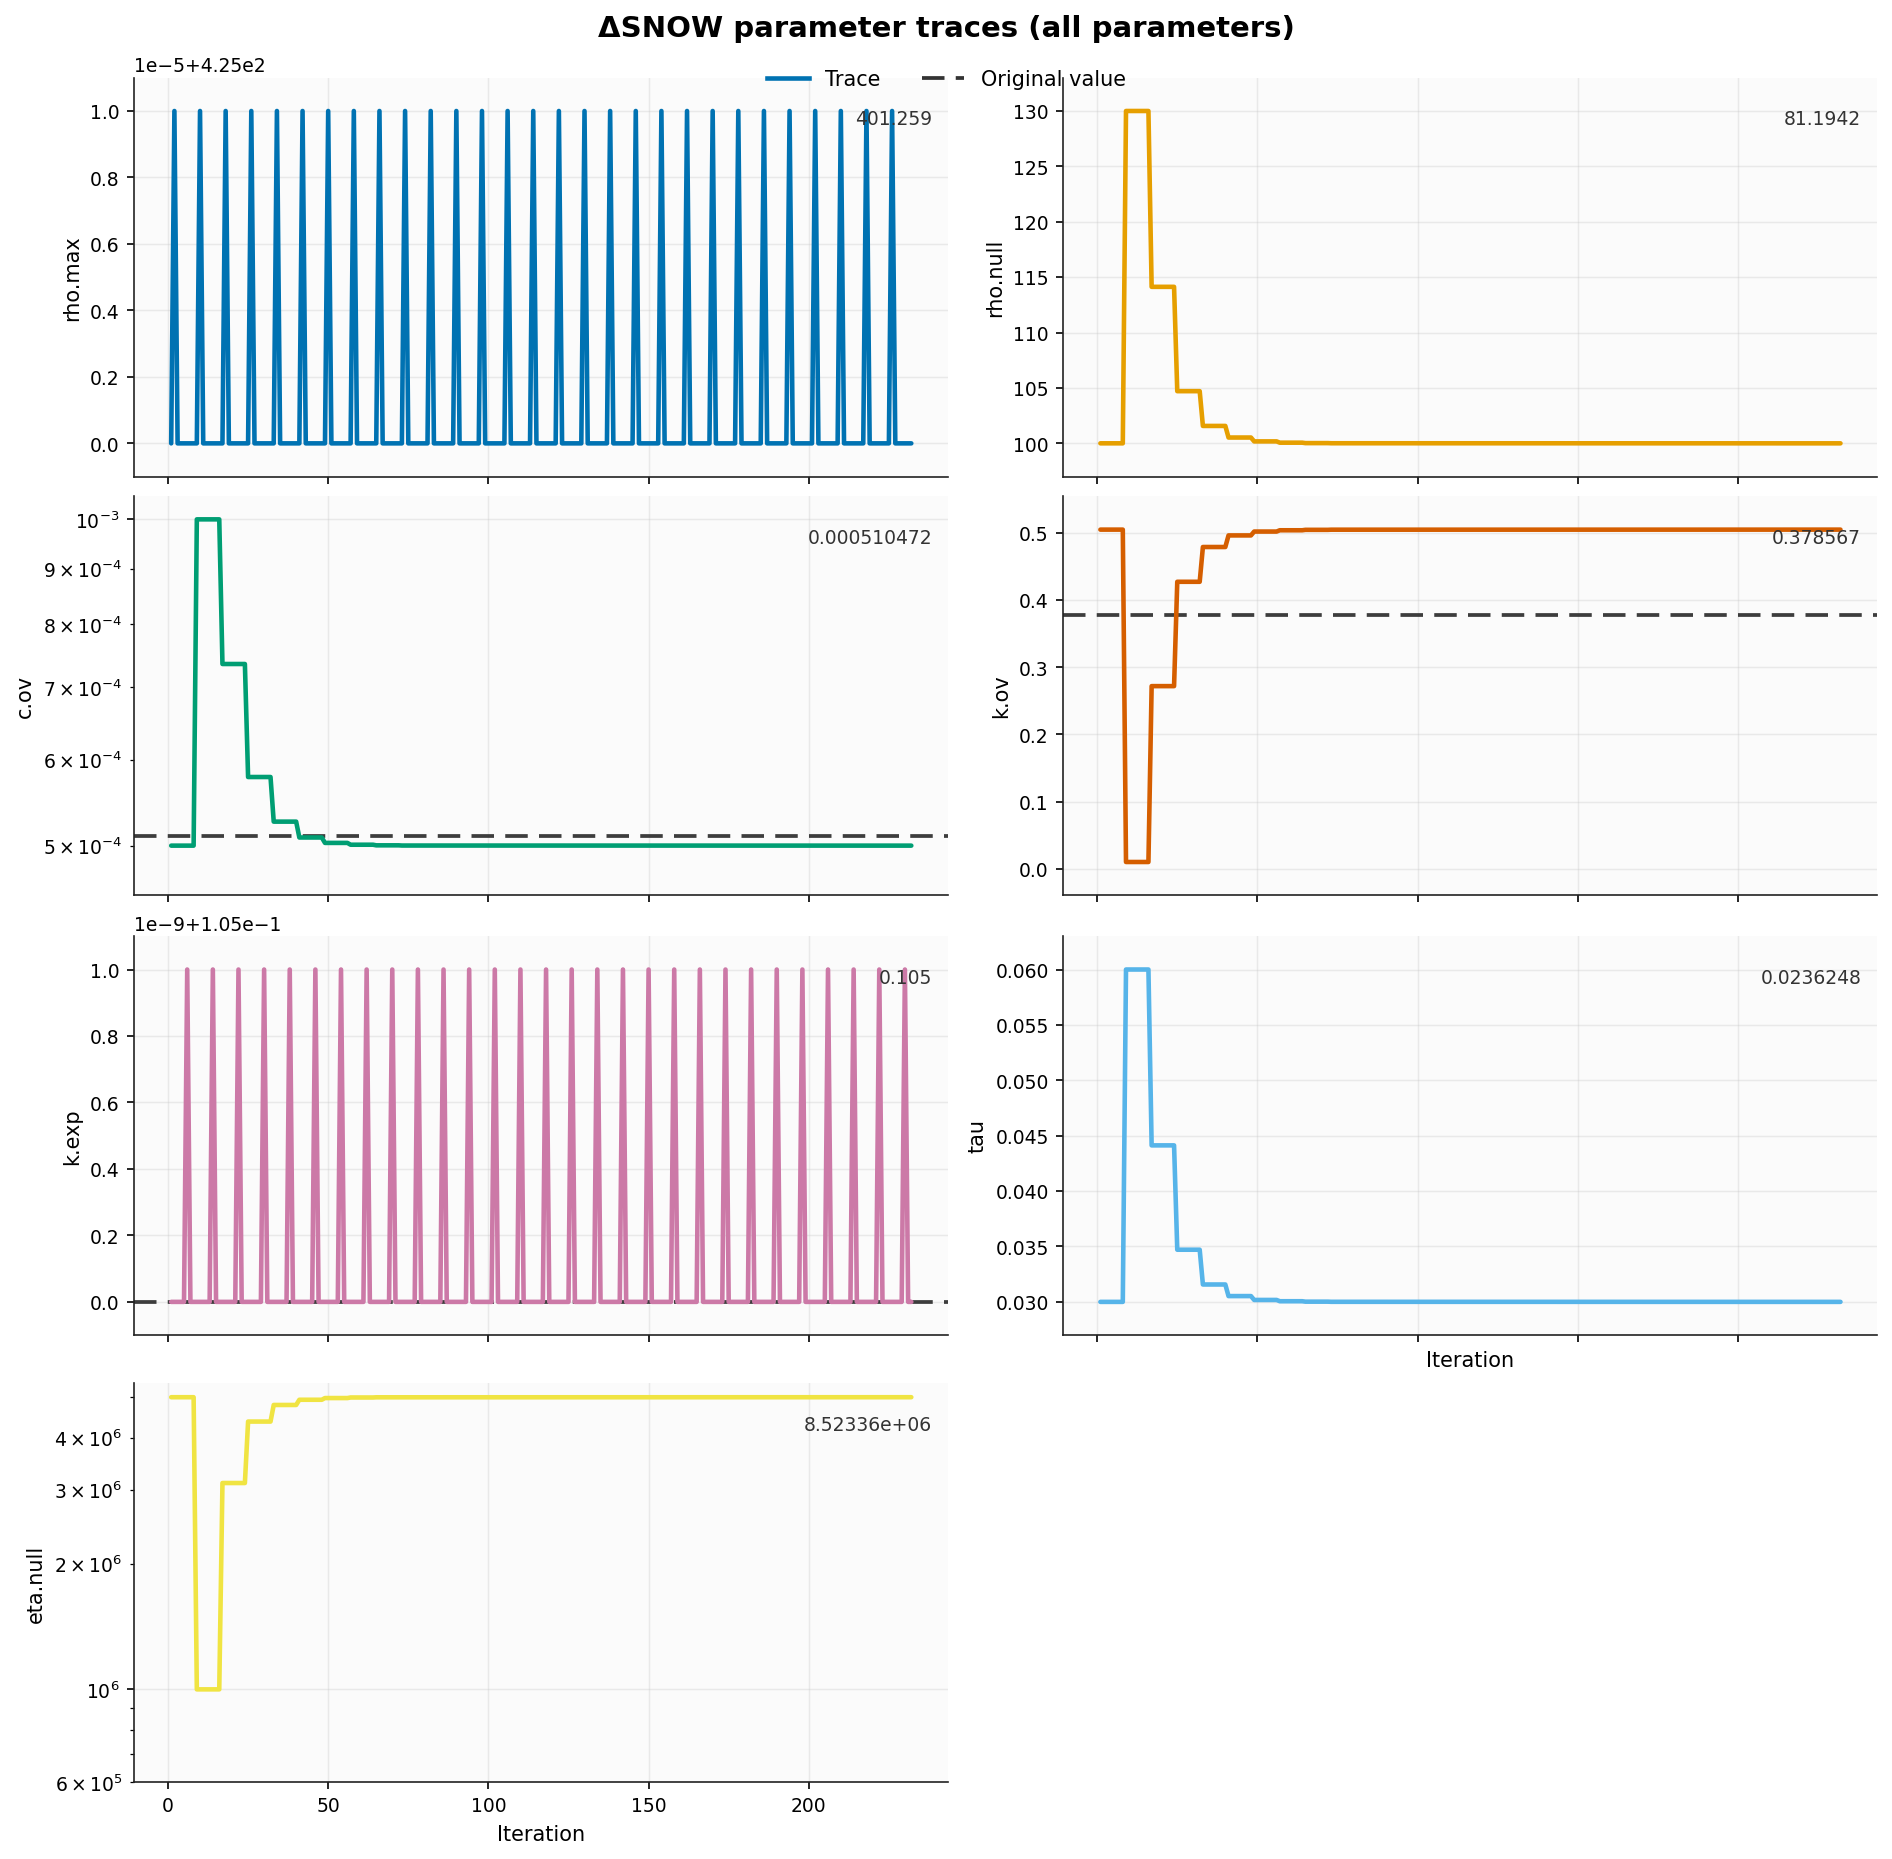

In [10]:
df = pd.read_csv("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/L-BFGS-B/finished_runs/exp_rsme_penalty/calibration_log.csv")

plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=param_cols,
    orig_params=dsnow_params,
    ncols=2,
    title="ΔSNOW parameter traces (all parameters)",
    log_params=("eta.null", "c.ov"),
)

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=None,
    orig_params=None,
    ncols=2,
    title="Parameter traces",
    log_params=("eta.null", "c.ov"),
):
    if orig_params is None:
        orig_params = {}

    if iteration_col in df.columns:
        x = df[iteration_col].to_numpy()
        xlab = "Iteration"
    else:
        x = np.arange(len(df))
        xlab = "Index"

    # Default: plot all numeric columns except iteration
    if param_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        param_cols = [c for c in numeric_cols if c != iteration_col]

    n = len(param_cols)
    nrows = math.ceil(n / ncols)

    palette = [
        "#0072B2", "#E69F00", "#009E73", "#D55E00",
        "#CC79A7", "#56B4E9", "#F0E442", "#000000",
    ]

    plt.rcParams.update({
        "figure.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.facecolor": "#FBFBFB",
        "figure.facecolor": "white",
        "axes.edgecolor": "#222222",
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#C9C9C9",
        "grid.linestyle": "-",
        "grid.linewidth": 0.7,
    })

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12.5, 3.0 * nrows),
        sharex=True,
        constrained_layout=True
    )
    axs = np.array(axs).reshape(-1)

    trace_handle = Line2D([0], [0], color=palette[0], lw=2.2, label="Trace")
    orig_handle  = Line2D([0], [0], color="#333333", lw=1.8, ls=(0, (6, 3)), label="Original value")

    for i, p in enumerate(param_cols):
        ax = axs[i]
        y = df[p].to_numpy(dtype=float)

        color = palette[i % len(palette)]
        ax.plot(x, y, color=color, lw=2.2, solid_capstyle="round", zorder=3)

        if p in orig_params:
            ref = float(orig_params[p])
            ax.axhline(ref, color="#333333", lw=1.8, ls=(0, (6, 3)), alpha=0.95, zorder=2)
            ax.text(
                0.98, 0.92, f"{ref:.6g}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=9,
                color="#333333"
            )

        ax.grid(True, alpha=0.35, zorder=1)
        ax.set_ylabel(p)

        if p in log_params:
            ymin = np.nanmin(y)
            ref_ok = (p not in orig_params) or (orig_params[p] > 0)
            if ymin > 0 and ref_ok:
                ax.set_yscale("log")

        q1, q99 = np.nanpercentile(y, [1, 99])
        if np.isfinite(q1) and np.isfinite(q99) and q1 != q99:
            pad = 0.10 * (q99 - q1)
            ax.set_ylim(q1 - pad, q99 + pad)

    for j in range(n, len(axs)):
        fig.delaxes(axs[j])

    # x-label on last row
    start_last_row = max(0, n - ncols)
    for ax in axs[start_last_row:n]:
        ax.set_xlabel(xlab)

    fig.suptitle(title, y=1.02, fontsize=14, fontweight="semibold")
    fig.legend(
        handles=[trace_handle, orig_handle],
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.00)
    )
    plt.show()

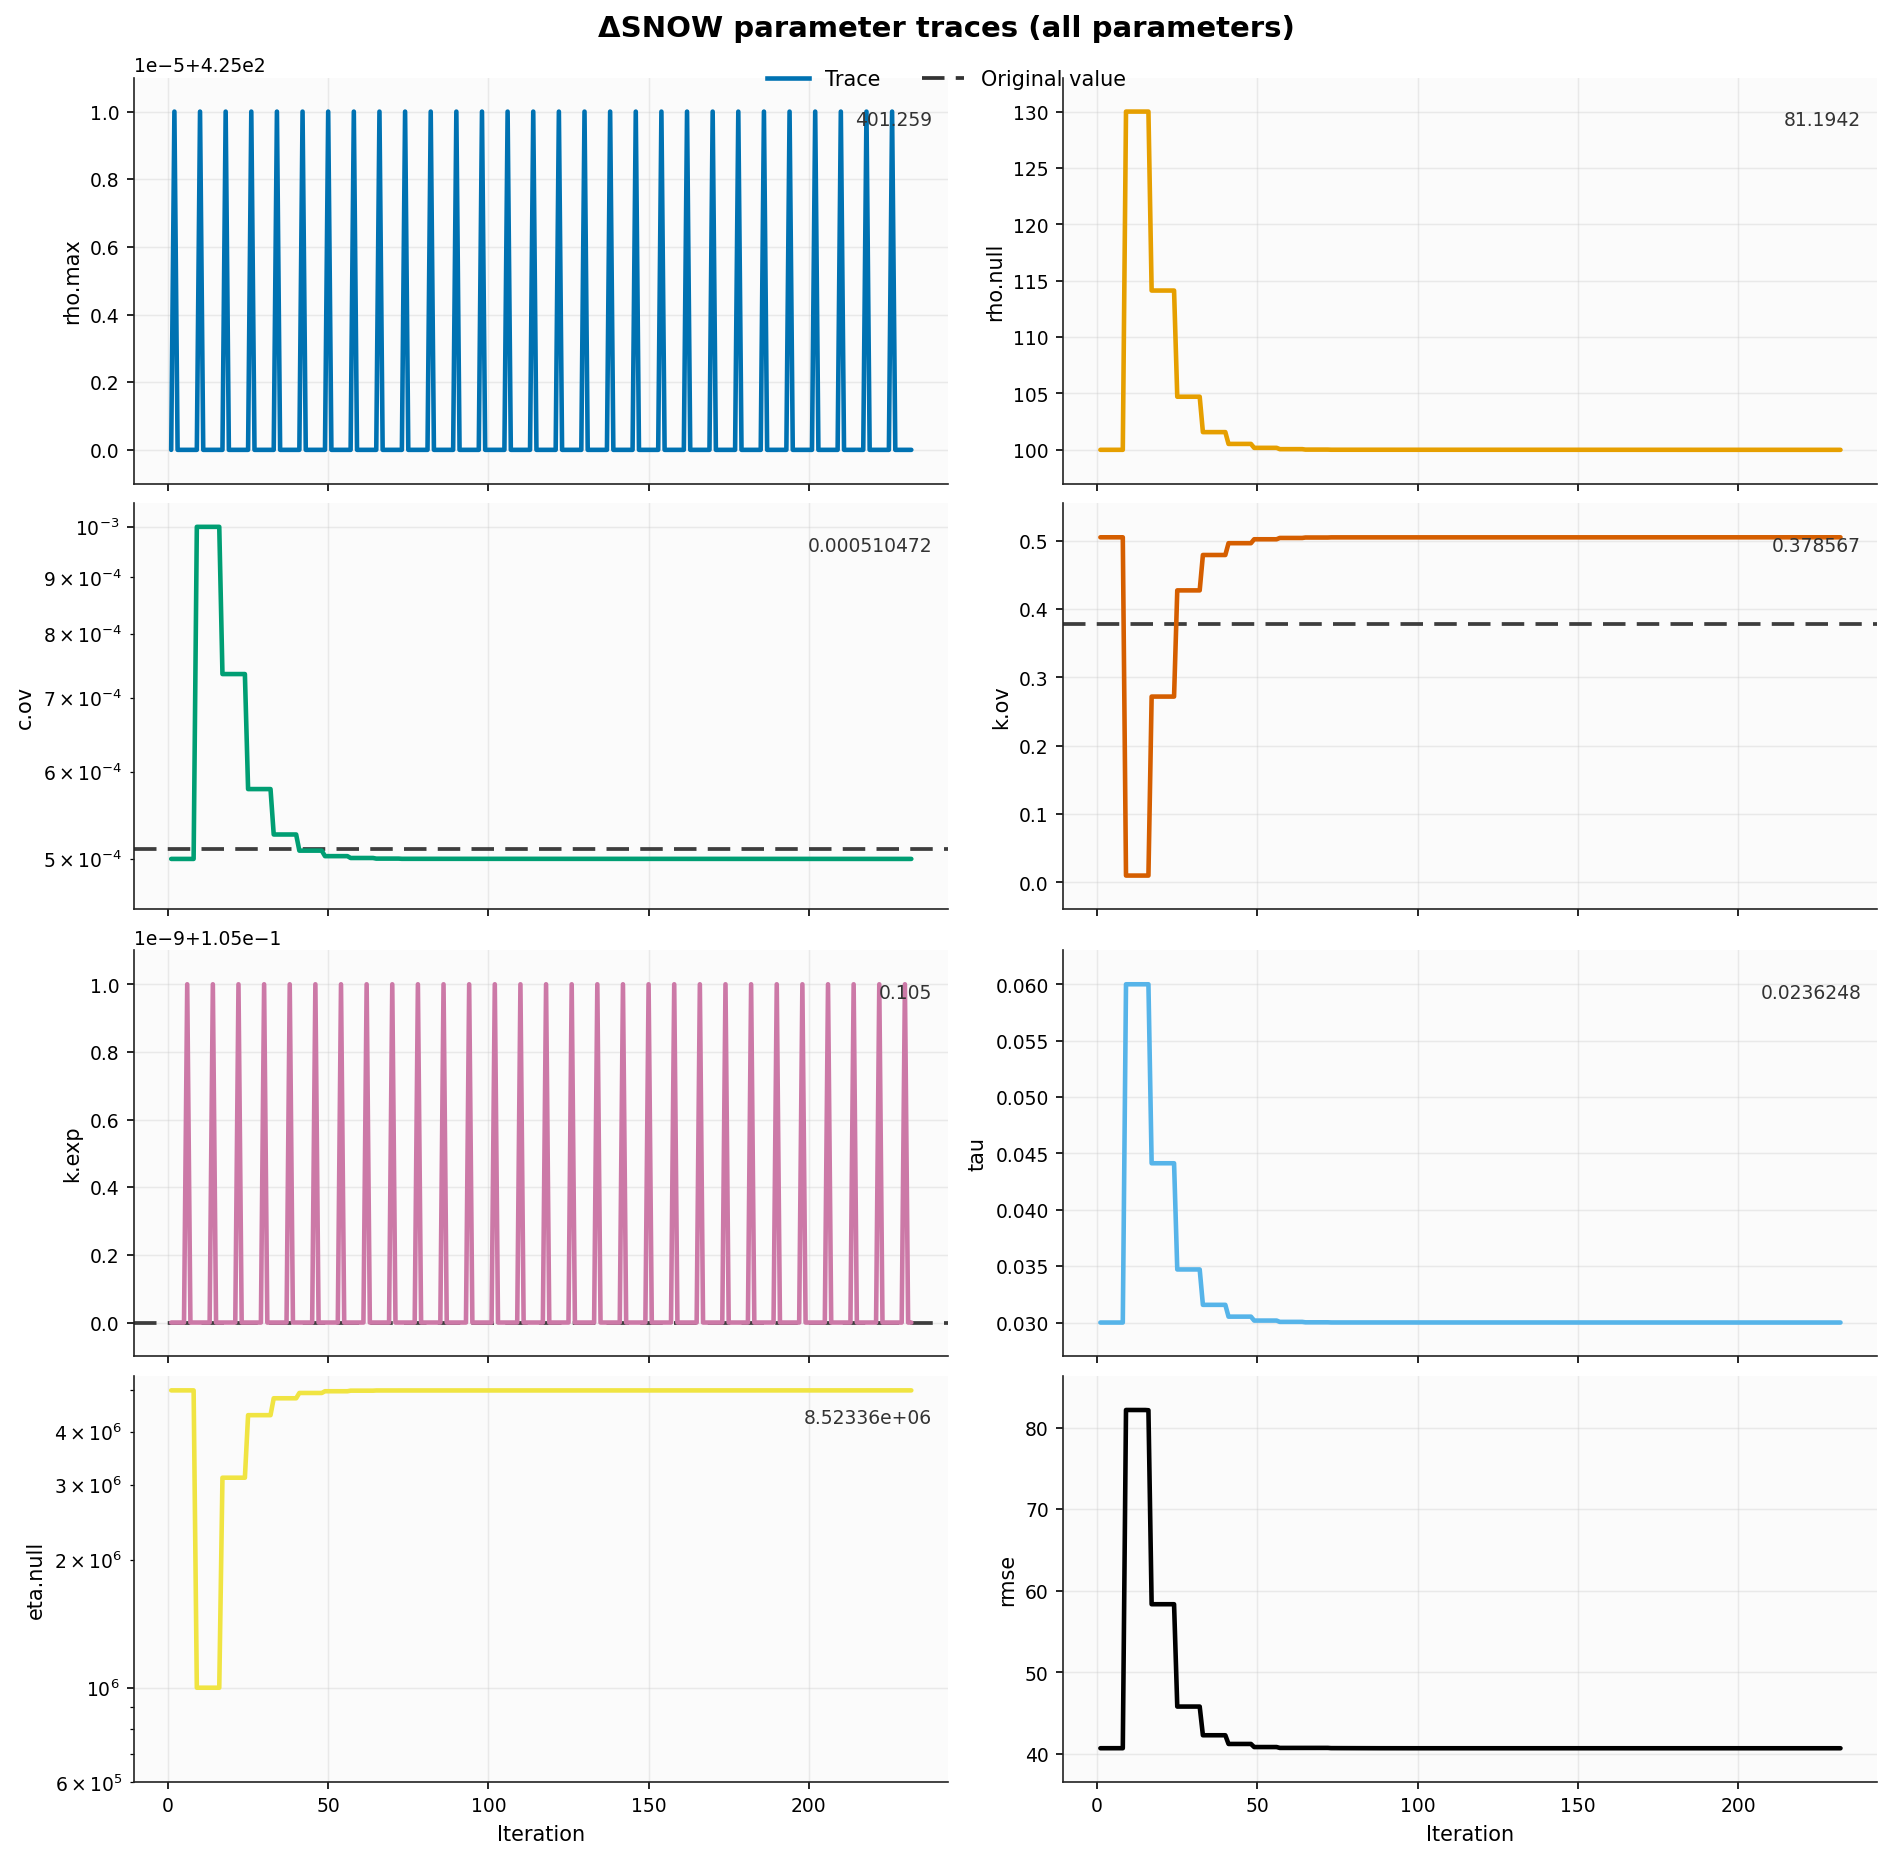

In [11]:
# Your "original" parameter values (update k.exp if you have it)
dsnow_params = {
    "rho.max": 401.2588,
    "rho.null": 81.19417,
    "c.ov": 0.0005104722,
    "k.ov": 0.37856737,
    "k.exp": 0.10499999999999998,   # <-- add if you want a reference line
    "tau": 0.02362476,
    "eta.null": 8523356,
}

param_cols = ["rho.max", "rho.null", "c.ov", "k.ov", "k.exp", "tau", "eta.null", "rmse"]

plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=param_cols,
    orig_params=dsnow_params,
    ncols=2,
    title="ΔSNOW parameter traces (all parameters)",
    log_params=("eta.null", "c.ov"),
)

[\rho_{i,t}=\rho_{i,t-1}\left(1+\Delta t \cdot\frac{\sigma_{i,t-1}}{\eta_0 \exp\!\left(k \rho_{i,t-1}\right)}\right)\]

Densification equations


dSNOW (density form):

$$
\rho_{i,t} = \rho_{i,t-1} \left( 1 + \Delta t \cdot \frac{\sigma_{i,t-1}}{\eta_0 \exp\left(k \rho_{i,t-1}\right)} \right)
$$

HS2SWE

$$
\rho_{i,t} = \rho_{i,t-1} \left[ 1 + \Delta t \left( \frac{\sigma_{i,t-1}}{\eta_0 \exp\left(c_4 T_s + c_5 \rho_{i,t-1}\right)} + c_1 \exp!\left(-c_2 T_s - c_3 \left(\rho_{i,t-1}-\rho_{\text{new}}\right)\right) \right) \right]
$$


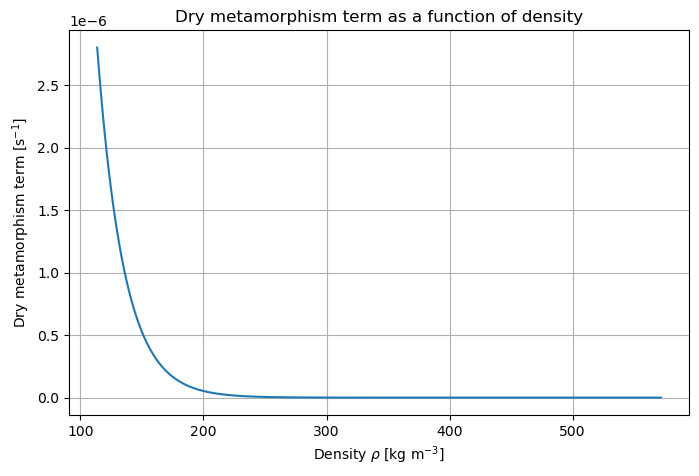

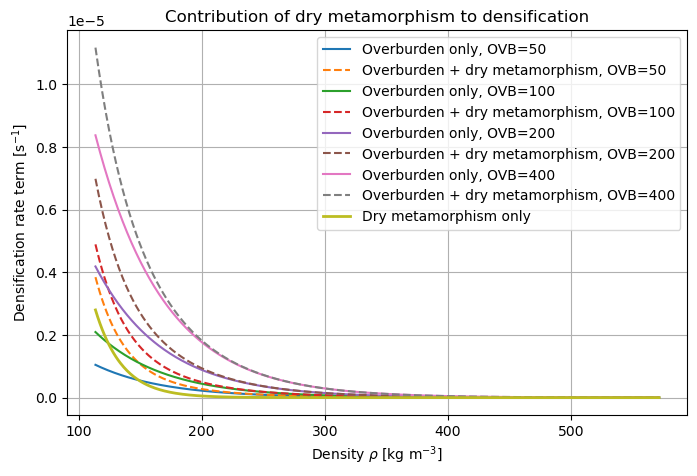

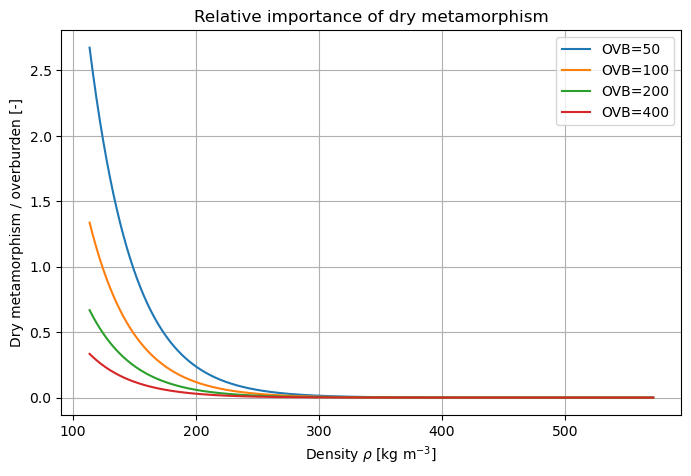

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters from HS2SWE
RhoNew = 113.7
RhoMax = 571.6
SnoTemp = -0.000
Visc = 6.051e7
c1 = 2.8e-6
c2 = 0.042
c3 = 0.046
c4 = 0.081
c5 = 0.018
g = 9.81
dt = 86400

# Parameters for the simpler delta-snow type overburden formulation
k = 0.030
nu_0 = 8.5e6

# Density range
rho = np.linspace(RhoNew, RhoMax, 500)

# Example overburden mass values [kg m^-2]
# You can change these to see the sensitivity
OVB_examples = [50, 100, 200, 400]

# Dry metamorphism term from your code
dry_meta = c1 * np.exp(-c2 * SnoTemp - c3 * np.maximum(0, rho - RhoNew))

# Plot 1: dry metamorphism term only
plt.figure(figsize=(8, 5))
plt.plot(rho, dry_meta)
plt.xlabel("Density $\\rho$ [kg m$^{-3}$]")
plt.ylabel("Dry metamorphism term [s$^{-1}$]")
plt.title("Dry metamorphism term as a function of density")
plt.grid(True)
plt.show()

# Plot 2: compare overburden term and dry metamorphism term
plt.figure(figsize=(8, 5))

for OVB in OVB_examples:
    overburden_term = (OVB * g) / (Visc * np.exp(c4 * SnoTemp + c5 * rho))
    total_term = overburden_term + dry_meta
    
    plt.plot(rho, overburden_term, label=f"Overburden only, OVB={OVB}")
    plt.plot(rho, total_term, linestyle="--", label=f"Overburden + dry metamorphism, OVB={OVB}")

plt.plot(rho, dry_meta, linewidth=2, label="Dry metamorphism only")
plt.xlabel("Density $\\rho$ [kg m$^{-3}$]")
plt.ylabel("Densification rate term [s$^{-1}$]")
plt.title("Contribution of dry metamorphism to densification")
plt.grid(True)
plt.legend()
plt.show()

# Plot 3: ratio of dry metamorphism to overburden term
plt.figure(figsize=(8, 5))

for OVB in OVB_examples:
    overburden_term = (OVB * g) / (Visc * np.exp(c4 * SnoTemp + c5 * rho))
    ratio = dry_meta / overburden_term
    plt.plot(rho, ratio, label=f"OVB={OVB}")

plt.xlabel("Density $\\rho$ [kg m$^{-3}$]")
plt.ylabel("Dry metamorphism / overburden [-]")
plt.title("Relative importance of dry metamorphism")
plt.grid(True)
plt.legend()
plt.show()

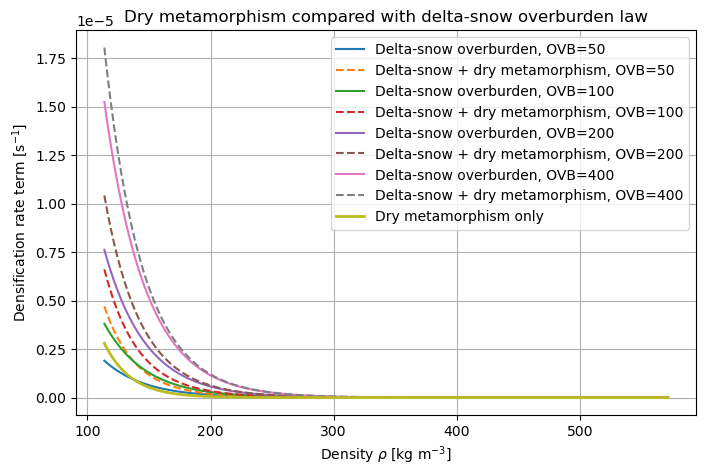

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
g = 9.81
k = 0.030
nu_0 = 8.5e6

# Same dry metamorphism parameters
RhoNew = 113.7
SnoTemp = 0.0
c1 = 2.8e-6
c2 = 0.042
c3 = 0.046

rho = np.linspace(RhoNew, 571.6, 500)
OVB_examples = [50, 100, 200, 400]

dry_meta = c1 * np.exp(-c2 * SnoTemp - c3 * np.maximum(0, rho - RhoNew))

plt.figure(figsize=(8, 5))

for OVB in OVB_examples:
    overburden_delta = (OVB * g) / (nu_0 * np.exp(k * rho))
    total = overburden_delta + dry_meta
    
    plt.plot(rho, overburden_delta, label=f"Delta-snow overburden, OVB={OVB}")
    plt.plot(rho, total, linestyle="--", label=f"Delta-snow + dry metamorphism, OVB={OVB}")

plt.plot(rho, dry_meta, linewidth=2, label="Dry metamorphism only")
plt.xlabel("Density $\\rho$ [kg m$^{-3}$]")
plt.ylabel("Densification rate term [s$^{-1}$]")
plt.title("Dry metamorphism compared with delta-snow overburden law")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
rho_diff = np.arange(0, 300)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

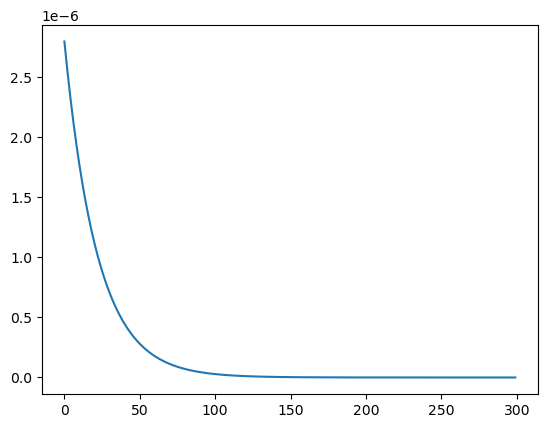

In [7]:
rho_diff = np.arange(0, 300)
dry_meta = c1 * np.exp(-c3 * rho_diff)
plt.plot(rho_diff, dry_meta)

# Big SMNOWFALL

In [14]:
import pandas as pd

csv_path = "/Users/jakobwerkgarner/code/mt_dsnow/model_diff/moduls/Dry_settling/synthetic_snowfalls/synthetic_big_snowfalls_100days.csv"
ds = pd.read_csv(csv_path)

ds.head()

,timestamp,HS_meas
0,2024-11-01,0.0
1,2024-11-02,0.0
2,2024-11-03,0.0
3,2024-11-04,0.0
4,2024-11-05,0.0


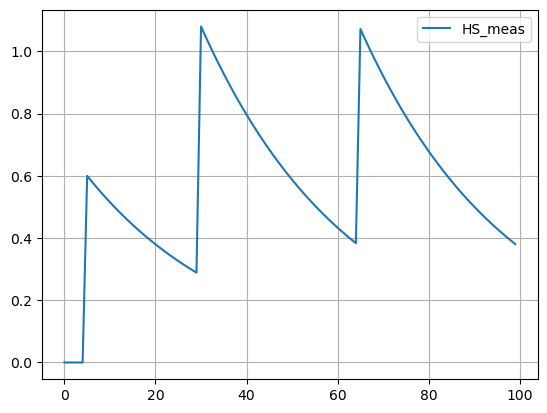

In [16]:
ds.plot()
plt.grid()

In [13]:


ds

<xarray.Dataset> Size: 54kB
Dimensions:     (layer: 11, time: 100)
Coordinates:
  * layer       (layer) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * time        (time) int32 400B 1 2 3 4 5 6 7 8 9 ... 93 94 95 96 97 98 99 100
Data variables:
    HS          (time, layer) float64 9kB ...
    SWE_layers  (time, layer) float64 9kB ...
    AGE         (time, layer) float64 9kB ...
    RHO         (time, layer) float64 9kB ...
    OVB         (time, layer) float64 9kB ...
    DIA         (time, layer) float64 9kB ...
    SWE         (time) float64 800B ...
Attributes:
    timestamps:  2024-11-01,2024-11-02,2024-11-03,2024-11-04,2024-11-05,2024-...

In [29]:
import pydeltasnow as pyds
import pandas as pd

In [39]:
import numpy as np
import pandas as pd
import pydeltasnow as pyds

data = pd.read_csv(
    "/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/output/HS_SWE_by_station/Adelboden_hs_swe_obs.csv"
)

data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").drop_duplicates(subset="date")

data_1year = data.iloc[:365].copy()

hs = (
    data_1year[["date", "hs"]]
    .assign(hs=lambda x: pd.to_numeric(x["hs"], errors="coerce"))
    .dropna(subset=["hs"])
    .set_index("date")["hs"]
    .astype(np.float64)
    .sort_index()
)

# force strictly regular daily index
full_index = pd.date_range(hs.index.min(), hs.index.max(), freq="D")
hs = hs.reindex(full_index)

# fill gaps with 0 if you want continuous daily series for DeltaSNOW
hs = hs.fillna(0.0).astype(np.float64)

# make absolutely sure values are plain float64
hs = pd.Series(
    np.ascontiguousarray(hs.to_numpy(dtype=np.float64)),
    index=hs.index,
    name="hs"
)

print(type(hs))
print(hs.dtype)
print(hs.index.inferred_freq)
print(hs.head())

swe = pyds.swe_deltasnow(hs)
print(swe.head())

<class 'pandas.core.series.Series'>
float64
D
2016-09-01    0.0
2016-09-02    0.0
2016-09-03    0.0
2016-09-04    0.0
2016-09-05    0.0
Freq: D, Name: hs, dtype: float64


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Cannot unify float64 and array(float64, 1d, C) for 'epsilon.2', defined at /Users/jakobwerkgarner/miniforge3/envs/pydeltasnow/lib/python3.9/site-packages/pydeltasnow/core.py (458)

File "../../../miniforge3/envs/pydeltasnow/lib/python3.9/site-packages/pydeltasnow/core.py", line 458:
def deltasnow_snowpack_evolution(
    <source elided>
                        epsilon = c_ov * sigma_null * np.exp(-k_ov * rho_dd / denom)
                    h[:, t] = (1 - epsilon) * h[:, t]
                    ^

During: typing of assignment at /Users/jakobwerkgarner/miniforge3/envs/pydeltasnow/lib/python3.9/site-packages/pydeltasnow/core.py (458)

File "../../../miniforge3/envs/pydeltasnow/lib/python3.9/site-packages/pydeltasnow/core.py", line 458:
def deltasnow_snowpack_evolution(
    <source elided>
                        epsilon = c_ov * sigma_null * np.exp(-k_ov * rho_d

In [40]:
print(hs.index.is_monotonic_increasing)
print(hs.index.is_unique)
print(pd.Series(hs.index[1:] - hs.index[:-1]).value_counts().head())

True
True
1 days    364
dtype: int64
